<a href="https://colab.research.google.com/github/Rupasri-555/ML-LAB/blob/main/Task_6(1)_In_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings


In [2]:
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd


In [4]:
import numpy as np


In [5]:
from sklearn.datasets import load_iris


In [6]:
from sklearn.preprocessing import StandardScaler


In [7]:
raw_iris = load_iris()


In [8]:
features = raw_iris.feature_names


In [9]:
X_raw = raw_iris.data


In [10]:
y_true = raw_iris.target


In [11]:
scaler = StandardScaler()


In [12]:
X_scaled = scaler.fit_transform(X_raw)


In [13]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)


In [14]:
iris_df['species_id'] = y_true


In [15]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}


In [16]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [17]:
print("Standardized dataset dimensions:", X_scaled.shape)


Standardized dataset dimensions: (150, 4)


In [18]:
print("\nFirst 3 rows of standardized dataset:")



First 3 rows of standardized dataset:


In [19]:
print(iris_df.head(3))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [20]:
cov_matrix = np.cov(X_scaled.T)


In [21]:
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [22]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [23]:
print("\nEigenvalues (Variance components):\n", eigenvalues)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [24]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [25]:
from sklearn.decomposition import PCA


In [26]:
pca_model = PCA(n_components=2, random_state=42)


In [27]:
X_pca = pca_model.fit_transform(X_scaled)


In [28]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])


In [29]:
pca_df['species_name'] = iris_df['species_name']


In [30]:
print("Transformed PCA space dimensions:", X_pca.shape)


Transformed PCA space dimensions: (150, 2)


In [31]:
print("\nFirst 3 projected coordinates:")



First 3 projected coordinates:


In [32]:
print(pca_df.head(3))


       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [33]:
import matplotlib.pyplot as plt


In [34]:
import seaborn as sns


In [35]:
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='PC_1', ylabel='PC2'>

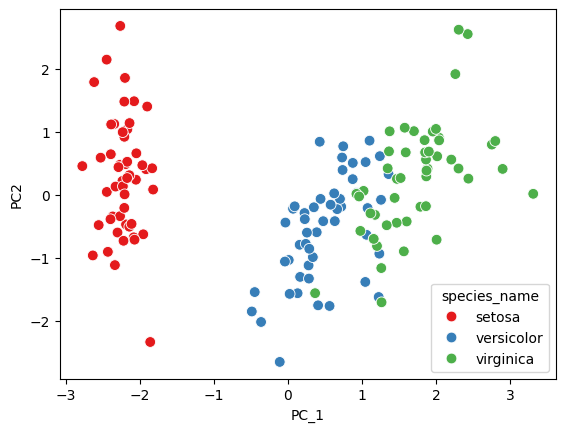

In [36]:
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)


Text(0.5, 1.0, '2-Component PCA Projection of Iris Dataset')

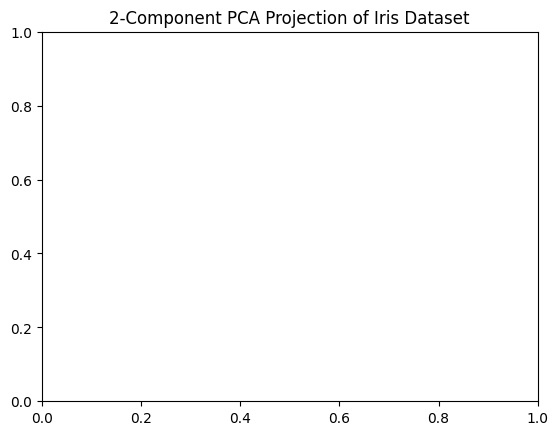

In [37]:
plt.title("2-Component PCA Projection of Iris Dataset")


Text(0.5, 0, 'Principal Component 1 (PC1)')

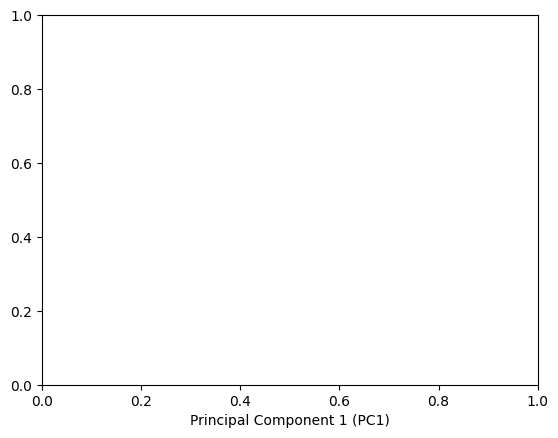

In [38]:
plt.xlabel("Principal Component 1 (PC1)")


Text(0, 0.5, 'Principal Component 2 (PC2)')

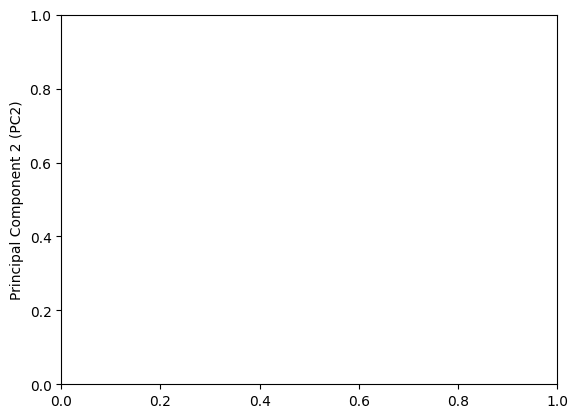

In [39]:
plt.ylabel("Principal Component 2 (PC2)")


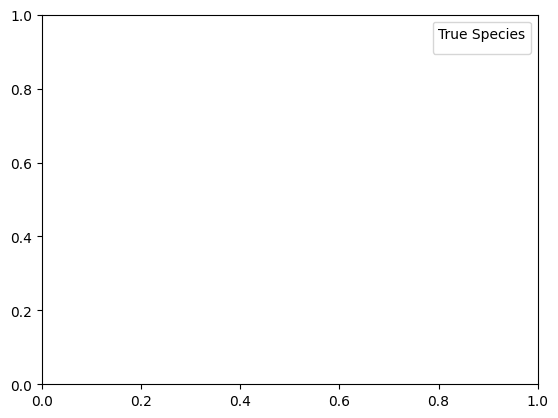

In [40]:
plt.legend(title='True Species')


In [41]:
plt.show()


In [42]:
explained_variance = pca_model.explained_variance_ratio_


In [43]:
cumulative_variance = np.sum(explained_variance)


In [44]:
print("Explained Variance per Component:")


Explained Variance per Component:


In [46]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

  PC1: 72.96%
  PC2: 22.85%


In [47]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")



Total Cumulative Variance Retained by 2 Components: 95.81%


In [48]:
import numpy as np


In [49]:
import pandas as pd


In [50]:
import matplotlib.pyplot as plt


In [51]:
from sklearn.datasets import load_iris


In [52]:
from sklearn.model_selection import train_test_split


In [53]:
from sklearn.preprocessing import StandardScaler


In [54]:
from sklearn.decomposition import PCA


In [55]:
from sklearn.linear_model import LogisticRegression


In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [57]:
iris = load_iris()


In [58]:
X = iris.data

In [59]:
y = iris.target

In [60]:
feature_names = iris.feature_names


In [61]:
target_names = iris.target_names


In [62]:
print("Dataset Shape:", X.shape)


Dataset Shape: (150, 4)


In [63]:
print("Features:", feature_names)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [64]:
print("Classes:", target_names)


Classes: ['setosa' 'versicolor' 'virginica']


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
scaler = StandardScaler()


In [67]:
X_train_scaled = scaler.fit_transform(X_train)


In [68]:
X_test_scaled = scaler.transform(X_test)


In [69]:
print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")


CLASSIFICATION WITHOUT PCA


In [70]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [71]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [72]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [73]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [74]:
print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")

Accuracy without PCA: 0.9333333333333333

Classification Report:


In [75]:
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [76]:
print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")



CLASSIFICATION WITH PCA


In [77]:
pca = PCA(
    n_components=2
)

In [78]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [79]:
X_test_pca = pca.transform(
    X_test_scaled
)

In [80]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72677234 0.23066667]


In [81]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

Total Explained Variance: 0.9574390106545363


In [82]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [83]:
model_with_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [84]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

In [85]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [86]:
print("Accuracy with PCA:",
      accuracy_with_pca)

Accuracy with PCA: 0.9


In [87]:
print("\nClassification Report:")



Classification Report:


In [88]:
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [89]:
print("\n========================================")
print("COMPARISON")
print("========================================")


COMPARISON


In [90]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

In [91]:
print(comparison)


        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [92]:
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

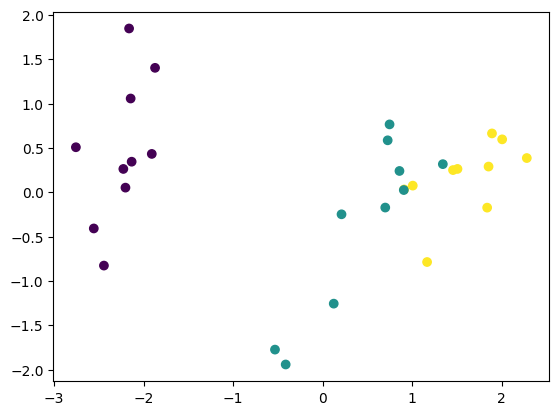

In [93]:
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

Text(0.5, 0, 'Principal Component 1')

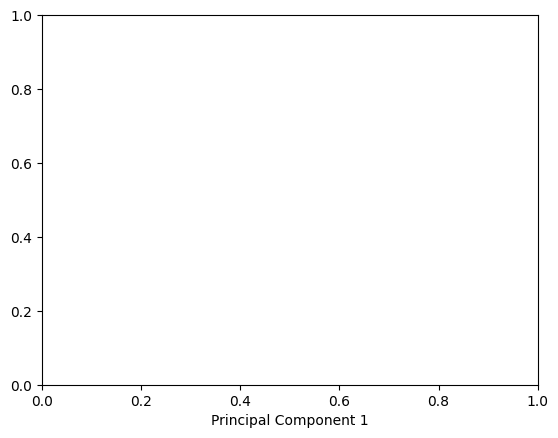

In [94]:
plt.xlabel("Principal Component 1")


Text(0, 0.5, 'Principal Component 2')

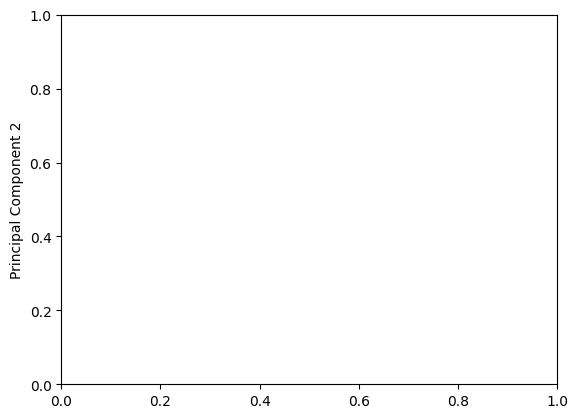

In [95]:
plt.ylabel("Principal Component 2")


Text(0.5, 1.0, 'Iris Classification Using PCA-24EU02026')

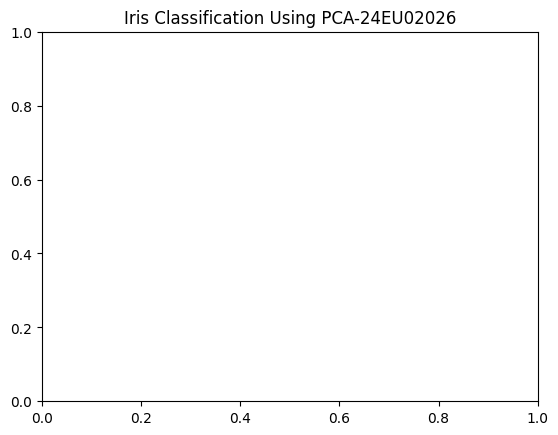

In [99]:
plt.title("Iris Classification Using PCA-24EU02026")


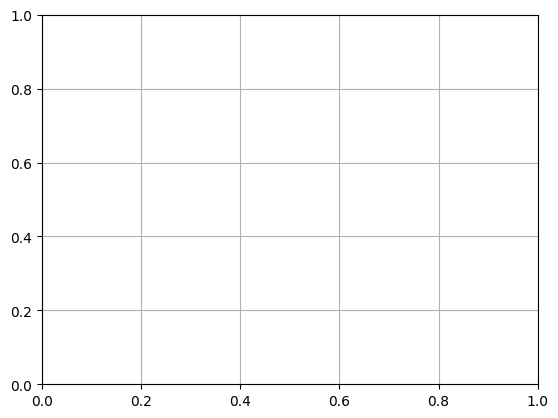

In [97]:
plt.grid()


In [98]:
plt.show()